In [1]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
# Load the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data Cleaning
df["job_posted_date"]=pd.to_datetime(df["job_posted_date"])
df["job_skills"]=df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)
df.info()


c:\Users\BAJWA LAPTOPS\.conda\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  str           
 1   job_title              785740 non-null  str           
 2   job_location           784696 non-null  str           
 3   job_via                785733 non-null  str           
 4   job_schedule_type      773074 non-null  str           
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  str           
 7   job_posted_date        785741 non-null  datetime64[us]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  str           
 11  salary_rate            33067 non-null   str           
 12  salary_year_avg        22003 non-null   float64       


In [20]:
df_DA_USA=df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')].copy()
df_DA_USA=df_DA_USA.dropna(subset=['salary_year_avg'])
df_DA_USA=df_DA_USA.explode('job_skills')
#skills_stat=df_DA_USA.groupby('job_skills').agg(count=('job_skills', 'size'), median_pay=('salary_year_avg', 'median'))
skills_stat=df_DA_USA.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])

skills_stat_top_pay=skills_stat.sort_values(by='median', ascending=False).head(10)
skills_stat_top_skills=skills_stat.sort_values(by='count', ascending=False).head(10)

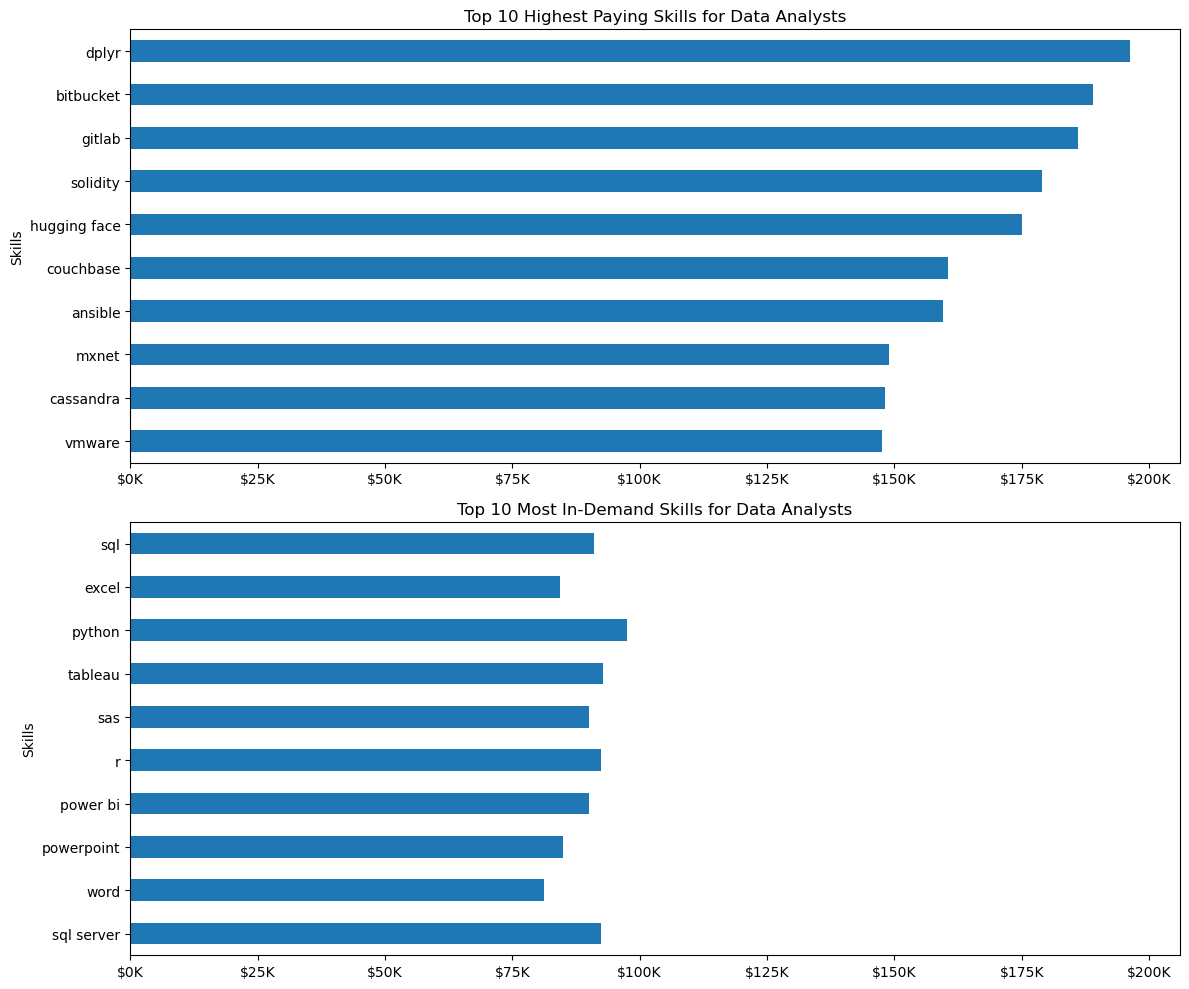

In [25]:
from matplotlib.ticker import FuncFormatter
fig, ax = plt.subplots(2,1, figsize=(12, 10))

skills_stat_top_pay.plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].set_title("Top 10 Highest Paying Skills for Data Analysts")
ax[0].set_xlabel("")
ax[0].set_ylabel("Skills")
ax[0].invert_yaxis()  # Invert y-axis to have the highest pay at the top
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:,.0f}K'))  # Format x-axis as currency

skills_stat_top_skills.plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title("Top 10 Most In-Demand Skills for Data Analysts")
ax[1].set_xlabel("")
ax[1].set_ylabel("Skills")
ax[1].invert_yaxis()  # Invert y-axis to have the most common skills at the top
ax[1].set_xlim(ax[0].get_xlim())  # Align x-axis limits for better comparison
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:,.0f}K'))  # Format x-axis as currency
plt.tight_layout()